# Exploring VAEs and MNIST handwriting data

## Introduction and Packages

In this notebook we test the numpy VAE implementation on the MNIST dataset. We require a few external libraries for visualization, data handling, and downstream tasks like clustering. You may find all the relevant packages in `environment.yml`.

## Loading the dataset

/opt/anaconda3/envs/numpy_VAE/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training data shape: (56000, 784)
Testing data shape: (14000, 784)


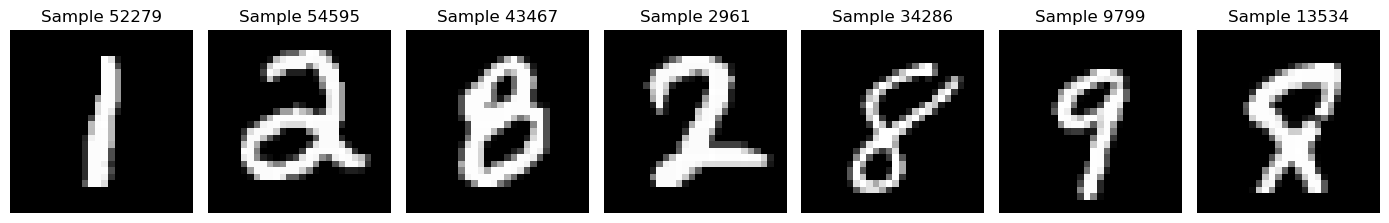

In [1]:
import numpy as np 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from src.utils import visualize_samples

#downloading MNIST dataset
print("Downloading MNIST...")
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)
X_full = mnist.data

# normalizing to (0,1)
X_full = X_full / 255

# train,test split
X_train, X_test = train_test_split(X_full, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}") 
print(f"Testing data shape: {X_test.shape}")

# checking out a few of the handwritten numbers
visualize_samples(X_train)

## Training VAE

We first initialize the VAE and adam optimizer. Feel free to play around with hyperparameters.

In [2]:
from src.model import VAE
from src.utils import AdamOptimizer

# hyperparam settings
hidden_dims = [512, 256]
latent_dims = 32
alpha = 1e-5

# initializing VAE
vae = VAE(input_dim = X_train.shape[1], hidden_dims = hidden_dims, latent_dim = latent_dims)
adam = AdamOptimizer(weights = vae.params, alpha = alpha)
print('Initialized VAE and ADAM optimzer')


Initialized VAE and ADAM optimzer


Let's see how well the VAE will reconstruct images without any training

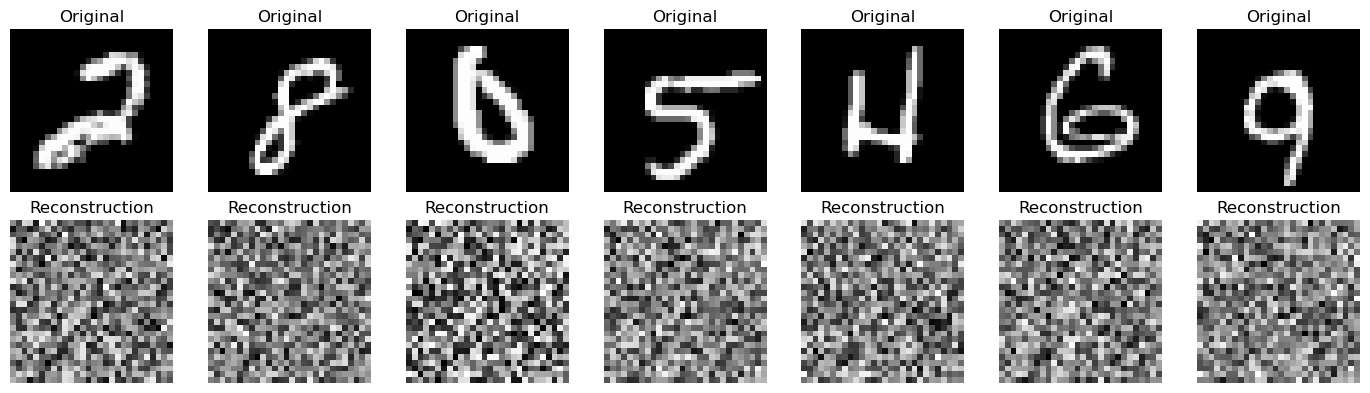

In [3]:
from src.utils import visualize_reconstruction

visualize_reconstruction(vae, X_train)

Let's now train for 5 epochs and see how well it is able to reconstruct images

Epoch 1/5 training...
Epoch 1/5 completed in 17.01 seconds with mean loss 462.737
Epoch 2/5 training...
Epoch 2/5 completed in 11.42 seconds with mean loss 280.746
Epoch 3/5 training...
Epoch 3/5 completed in 12.67 seconds with mean loss 242.257
Epoch 4/5 training...
Epoch 4/5 completed in 13.89 seconds with mean loss 224.644
Epoch 5/5 training...
Epoch 5/5 completed in 16.29 seconds with mean loss 212.497


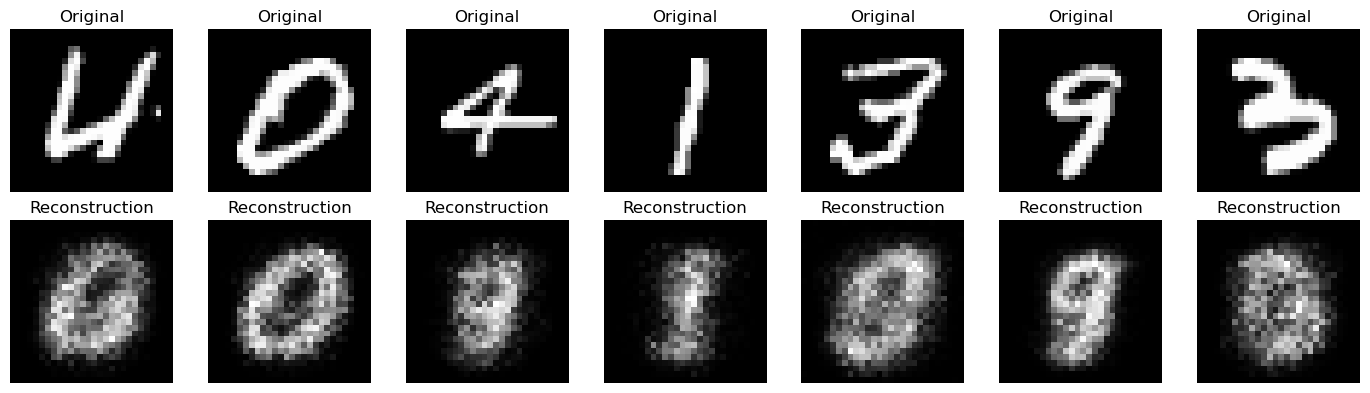

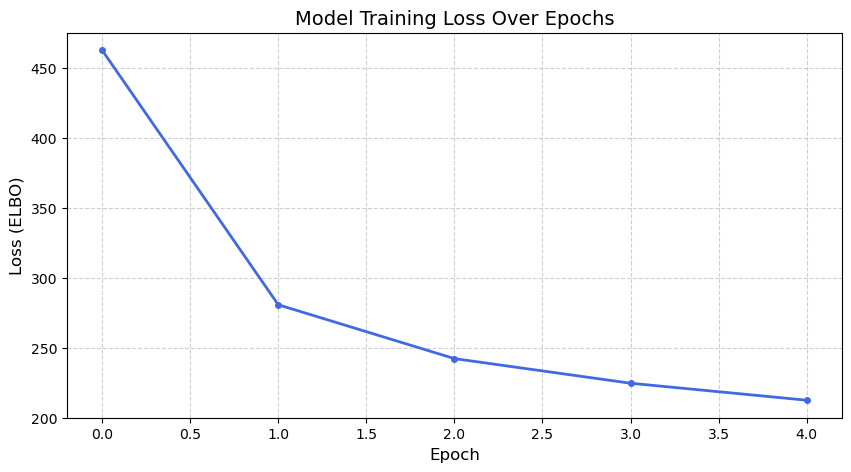

In [4]:
from src.train import train
from src.utils import visualize_loss

vae, epoch_loss = train(vae, adam, X_train, epochs = 5, batch_size = 128)

visualize_reconstruction(vae, X_train)

visualize_loss(epoch_loss)

Lets instead train with 15 epochs and see how it performs.

Epoch 1/15 training...
Epoch 1/15 completed in 13.95 seconds with mean loss 478.754
Epoch 2/15 training...
Epoch 2/15 completed in 12.25 seconds with mean loss 289.255
Epoch 3/15 training...
Epoch 3/15 completed in 13.40 seconds with mean loss 247.400
Epoch 4/15 training...
Epoch 4/15 completed in 12.64 seconds with mean loss 228.350
Epoch 5/15 training...
Epoch 5/15 completed in 12.57 seconds with mean loss 213.207
Epoch 6/15 training...
Epoch 6/15 completed in 23.59 seconds with mean loss 198.752
Epoch 7/15 training...
Epoch 7/15 completed in 27.66 seconds with mean loss 190.243
Epoch 8/15 training...
Epoch 8/15 completed in 20.58 seconds with mean loss 184.989
Epoch 9/15 training...
Epoch 9/15 completed in 20.19 seconds with mean loss 181.990
Epoch 10/15 training...
Epoch 10/15 completed in 17.03 seconds with mean loss 179.846
Epoch 11/15 training...
Epoch 11/15 completed in 22.99 seconds with mean loss 178.488
Epoch 12/15 training...
Epoch 12/15 completed in 22.56 seconds with mean

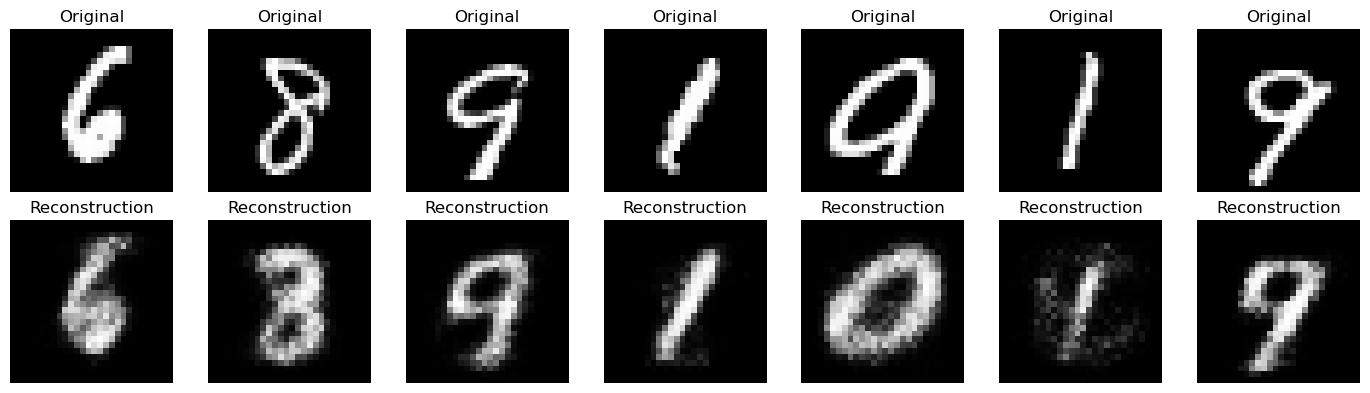

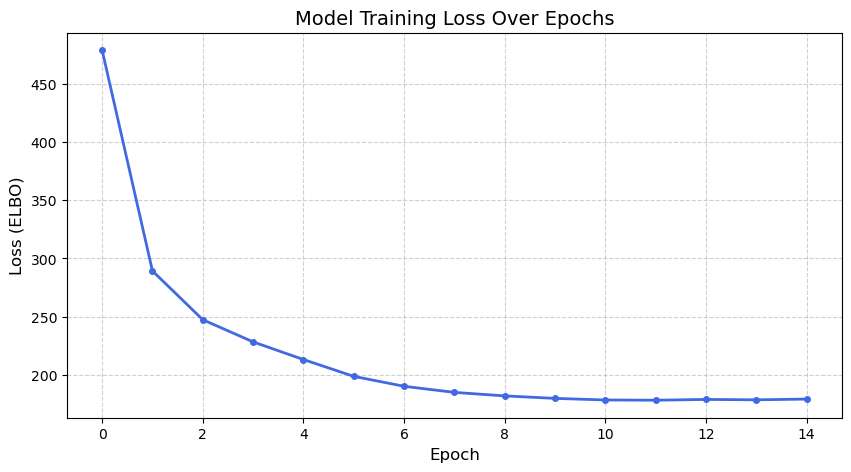

In [5]:
vae = VAE(input_dim = X_train.shape[1], hidden_dims = hidden_dims, latent_dim = latent_dims)
adam = AdamOptimizer(weights = vae.params, alpha = alpha)

vae, epoch_loss = train(vae, adam, X_train, epochs = 15, batch_size = 128, patience=3)

visualize_reconstruction(vae, X_train)

visualize_loss(epoch_loss)

Finally, lets test it on the witheld test data.

The test loss is 179.242


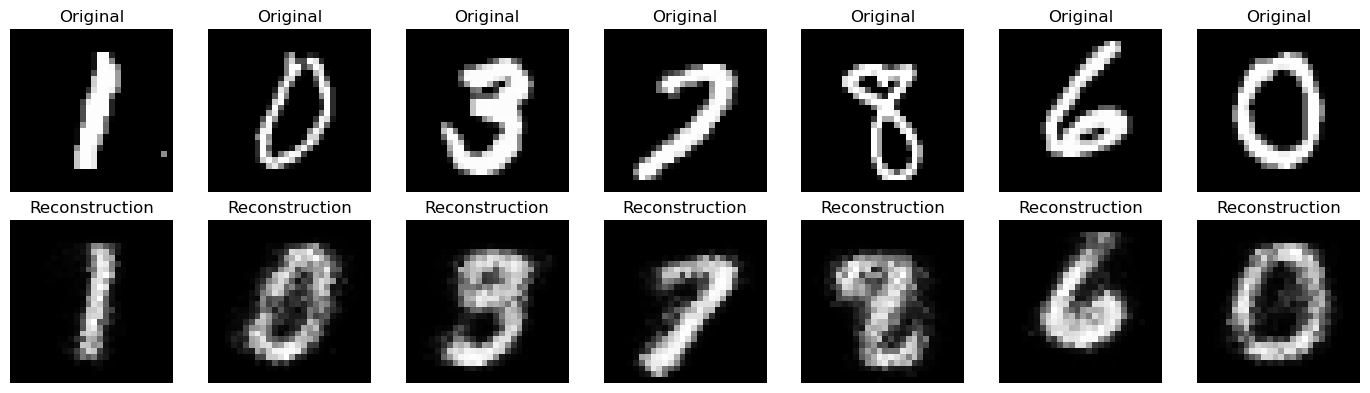

In [6]:
_, loss = vae.full_pass(X_test)

print(f'The test loss is {loss:.3f}')

visualize_reconstruction(vae, X_test)

## Connections to Single Cell data

Now, lets see why VAEs like scVI are very helpful for analyzing single cell data.

Imagine, instead of passing flattened black and white images through the VAE, our data were gene expression vectors. Obviously, its pretty easy to display the image and visually identify what type the number is. For a gene expression vector, which have thousands of entries, you cannot inspect it. There will also be significantly more noise involved.

To determine cell types, we will use the latent representation of the data. This ought to be viewed as a compressed and denoised form of gene expression data, in which we extract from the gene expression whatever determines cell type. Mathematically, this aligns with the model as the latent variable $z$ encodes the cell type, while $p_\theta(x|z)$ is the actual, much noisier, gene expression.

Typically we run KNN, Leiden clustering, and a non-linear projection of the clustered latent space onto two dimensions to visualize each cell type. In theory, this allows us to identify, different cell types.

Let's see how this method carries over in the context of hand written numbers. Below are two plots. First, the cluster the latent representation. Second, original and reconstructed images corresponding to points in each cluster. Note that clusters are not always the same. Like everything in ML there is an art to setting hyperparameters, and the model will never be perfect.

/opt/anaconda3/envs/numpy_VAE/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


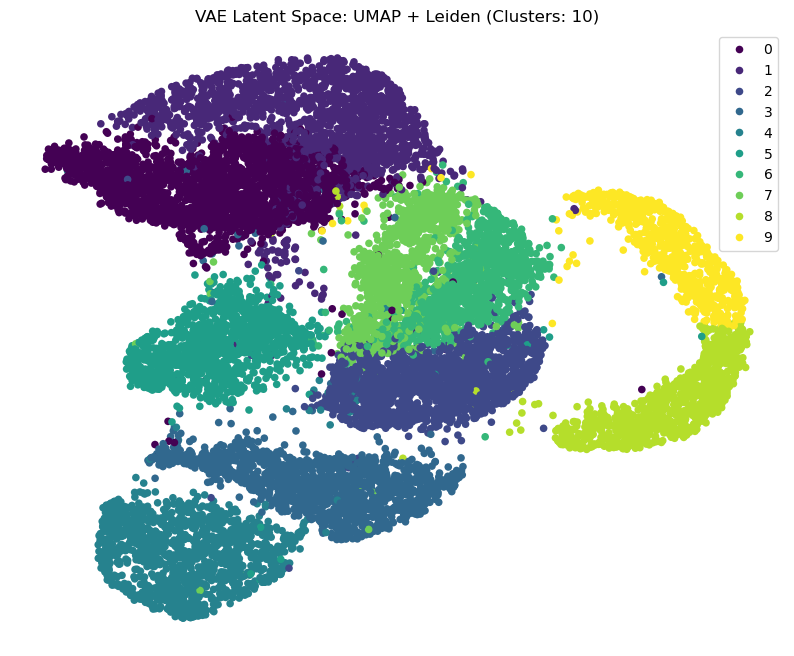

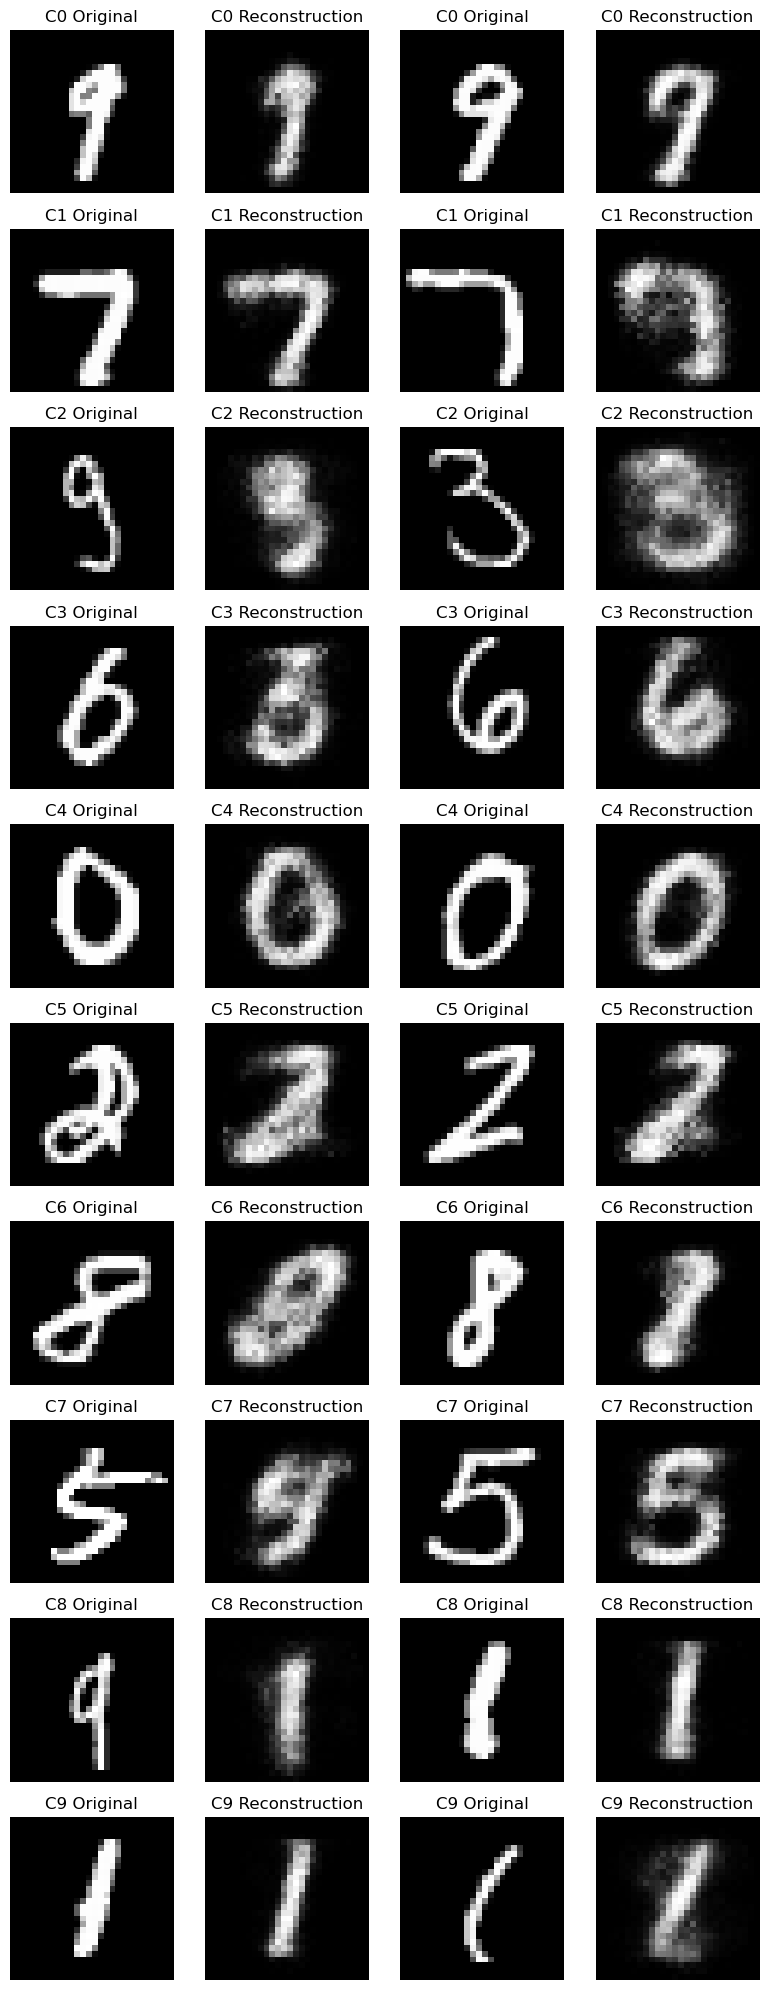

In [15]:
from src.utils import cluster_reconstruction

cluster_reconstruction(vae, X_test)